# Fe²⁺ Oxidation in a Phosphate Growth Medium — Kinetics and Speciation

This notebook models the abiotic oxidation of dissolved ferrous iron (Fe²⁺) to ferric iron
(Fe³⁺) in a rich phosphate–ammonium growth medium representative of many bioprocess and
hydrometallurgical applications.

Three coupled chemical subsystems interact at every time step:

- **Kinetic** oxidation by dissolved O₂ via the Singer-Stumm rate law
  $r = k_S\,[\text{Fe}^{2+}][\text{O}_2][\text{OH}^-]^2$ — the [OH⁻]² dependence
  makes this reaction exquisitely sensitive to the buffer environment.
- **Phosphate speciation** — the H₃PO₄/H₂PO₄⁻/HPO₄²⁻/PO₄³⁻ ladder buffers the system
  around pH 4.7, modulating [OH⁻] and hence the oxidation rate.
- **Fe(III) speciation** — instantaneous hydrolysis of the oxidation product into
  FeOH²⁺ and Fe(OH)₂⁺, releasing H⁺ and competing against the OH⁻ produced by the kinetic step.

## 1  Chemistry Design Basis

### 1.1  Growth medium

| Salt | g/L | MW (g/mol) | mol/L |
|---|---|---|---|
| KH₂PO₄ | 30.0 | 136.09 | 0.2204 |
| NH₄Cl | 5.5 | 53.49 | 0.1028 |
| K₂SO₄ | 0.4 | 174.26 | 0.00230 |
| MgSO₄·7H₂O | 0.4 | 246.47 | 0.00162 |

Dissolved ions after dissociation (Fe²⁺ added as FeSO₄):

| Ion | mol/L | Source |
|---|---|---|
| K⁺ | 0.2250 | KH₂PO₄ (0.2204) + K₂SO₄ (0.0046) |
| H₂PO₄⁻ | 0.2204 | KH₂PO₄ (distributes under pH control) |
| NH₄⁺ | 0.1028 | NH₄Cl (pKa 9.25 → ~100% NH₄⁺ at pH 4–5) |
| Cl⁻ | 0.1028 | NH₄Cl |
| SO₄²⁻ | 0.00592 | K₂SO₄ (0.0023) + MgSO₄ (0.0016) + FeSO₄ (0.0020) |
| Mg²⁺ | 0.00162 | MgSO₄·7H₂O |
| Fe²⁺ | 0.00200 | Added as FeSO₄ |
| O₂ (aq) | 0.00075 | Initial dissolved O₂ (0.75 mM ≈ 3× atmospheric saturation) |

Natural pH dominated by the KH₂PO₄ amphoteric point:
$\text{pH} \approx (\text{p}K_{a1} + \text{p}K_{a2})/2 = (2.15 + 7.20)/2 = \mathbf{4.68}$

### 1.2  Kinetic reaction

| Reaction | Rate law | Note |
|---|---|---|
| 4 Fe²⁺ + O₂ + 2 H₂O → 4 Fe³⁺ + 4 OH⁻ | $r = k_S\,[\text{Fe}^{2+}][\text{O}_2][\text{OH}^-]^2\,V_L$ | Singer-Stumm (1970); k scaled ≈10⁹× for hour-scale demo at pH 4.7 |

The Singer-Stumm rate grows as [OH⁻]²: it increases 100-fold per pH unit.
At pH < 5, the real reaction takes days to months; the demo constant is scaled to
produce a 1–3 h half-life while preserving the correct functional form and pH sensitivity.

### 1.3  Equilibrium reactions

| Reaction | log K (25 °C) | anchor |
|---|---|---|
| H₂O ⇌ H⁺ + OH⁻ | −14.00 | water |
| H₃PO₄ ⇌ H₂PO₄⁻ + H⁺ | −2.15 | H3PO4 |
| H₂PO₄⁻ ⇌ HPO₄²⁻ + H⁺ | −7.20 | H3PO4 |
| HPO₄²⁻ ⇌ PO₄³⁻ + H⁺ | −12.35 | H3PO4 |
| NH₄⁺ ⇌ NH₃ + H⁺ | −9.25 | NH3 |
| Fe³⁺ + H₂O ⇌ FeOH²⁺ + H⁺ | −2.19 | Fe3+ |
| FeOH²⁺ + H₂O ⇌ Fe(OH)₂⁺ + H⁺ | −3.48 | Fe3+ |

Phosphate pKa: Martell & Smith (1977). Iron hydrolysis: Liu & Millero (1999).

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def _find_repo():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / 'pyproject.toml').exists():
            return p
    raise RuntimeError('Run from inside the PyOMES repo')

sys.path.insert(0, str(_find_repo() / 'models'))

from PyOMES.chemistry import Species
from PyOMES.chemistry.common_species import (
    H2O, H_plus, OH_minus,
    H3PO4, H2PO4_minus, HPO4_2minus, PO4_3minus,
    NH3, NH4_plus,
    K_plus, Na_plus, Cl_minus, HSO4_minus, SO4_2minus,
    Mg_plus_plus, Ca_plus_plus, Zn_plus_plus, Mn_plus_plus,
    Cu_plus_plus, Co_plus_plus, MoO4_2minus,
)
from PyOMES.reactions import (
    KineticReaction, EquilibriumReaction, ReactionSystem, StoichiometryEntry,
)
from PyOMES.core import LiquidPhase, ControlVolume, Simulation

def _e(sp, coeff):
    return StoichiometryEntry(species=sp, phase='liquid', coefficient=coeff)

print('Imports OK')

Imports OK


## 2  Species, Reactions, and Speciation Design

### 2.1  Species

In [2]:
# Iron species — atoms dict drives MW auto-computation and element balance validation
Fe2_plus = Species(id='Fe2+',      atoms={'Fe': 1},                  charge=+2)
Fe3_plus = Species(id='Fe3+',      atoms={'Fe': 1},                  charge=+3)
FeOH_2p  = Species(id='FeOH2+',   atoms={'Fe': 1, 'O': 1, 'H': 1}, charge=+2)
FeOH2_p  = Species(id='Fe(OH)2+', atoms={'Fe': 1, 'O': 2, 'H': 2}, charge=+1)

# Dissolved oxidant
O2_aq = Species(id='O2', atoms={'O': 2}, charge=0)

# Organic recipe components.  Citrate is included as its neutral acid form;
# metal-citrate complexation is deliberately outside this first composition pass.
H3Cit = Species(id='H3Cit', atoms={'C': 6, 'H': 8, 'O': 7}, charge=0)
Biotin = Species(id='Biotin', atoms={'C': 10, 'H': 16, 'N': 2, 'O': 3, 'S': 1}, charge=0)

for sp in [Fe2_plus, Fe3_plus, FeOH_2p, FeOH2_p, O2_aq, H3Cit, Biotin]:
    print(f'  {sp.id:<14}  MW = {float(sp.MW):.3f} g/mol  charge = {sp.charge:+d}')

  Fe2+            MW = 55.845 g/mol  charge = +2
  Fe3+            MW = 55.845 g/mol  charge = +3
  FeOH2+          MW = 72.852 g/mol  charge = +2
  Fe(OH)2+        MW = 89.859 g/mol  charge = +1
  O2              MW = 31.998 g/mol  charge = +0
  H3Cit           MW = 192.123 g/mol  charge = +0
  Biotin          MW = 244.314 g/mol  charge = +0


### 2.2  Kinetic and equilibrium reactions

In [3]:
# ── Water equilibrium ────────────────────────────────────────────────────────
rxn_water = EquilibriumReaction(
    stoichiometry=[_e(H2O, -1), _e(H_plus, +1), _e(OH_minus, +1)],
    log_K=-14.0, label='water',
)

# ── Phosphate ladder (Martell & Smith 1977) ──────────────────────────────────
rxn_p1 = EquilibriumReaction(
    stoichiometry=[_e(H3PO4, -1), _e(H2PO4_minus, +1), _e(H_plus, +1)],
    log_K=-2.15, total_id='H3PO4', label='P_pKa1',
)
rxn_p2 = EquilibriumReaction(
    stoichiometry=[_e(H2PO4_minus, -1), _e(HPO4_2minus, +1), _e(H_plus, +1)],
    log_K=-7.20, total_id='H3PO4', label='P_pKa2',
)
rxn_p3 = EquilibriumReaction(
    stoichiometry=[_e(HPO4_2minus, -1), _e(PO4_3minus, +1), _e(H_plus, +1)],
    log_K=-12.35, total_id='H3PO4', label='P_pKa3',
)

# ── Ammonium equilibrium ─────────────────────────────────────────────────────
rxn_nh4 = EquilibriumReaction(
    stoichiometry=[_e(NH4_plus, -1), _e(NH3, +1), _e(H_plus, +1)],
    log_K=-9.25, total_id='NH3', label='NH4',
)

# ── Sulfate acid-base equilibrium ────────────────────────────────────────────
# Required because SO₄²⁻ is loaded with K₂SO₄, MgSO₄, and FeSO₄.
# This total sulfate component must participate in charge balance.
rxn_sulfate = EquilibriumReaction(
    stoichiometry=[_e(HSO4_minus, -1), _e(H_plus, +1), _e(SO4_2minus, +1)],
    log_K=-1.99, total_id='HSO4-', label='HSO4_pKa2',
)

# ── Fe³⁺ hydrolysis (Liu & Millero 1999) ────────────────────────────────────
rxn_fe3_h1 = EquilibriumReaction(
    stoichiometry=[_e(Fe3_plus, -1), _e(H2O, -1), _e(FeOH_2p, +1), _e(H_plus, +1)],
    log_K=-2.19, total_id='Fe3+', label='Fe3_h1',
)
rxn_fe3_h2 = EquilibriumReaction(
    stoichiometry=[_e(FeOH_2p, -1), _e(H2O, -1), _e(FeOH2_p, +1), _e(H_plus, +1)],
    log_K=-3.48, total_id='Fe3+', label='Fe3_h2',
)

# ── Singer-Stumm kinetic oxidation by O₂ ────────────────────────────────────
# Stoichiometry: 4 Fe²⁺ + O₂ + 2 H₂O → 4 Fe³⁺ + 4 OH⁻
# Balance: Fe 4=4, O 2+2=4=4✓, H 4=4✓, charge 8→12−4=8✓
# rate_fn = extensive rate (mol extent / h) = K_SS × [Fe²⁺][O₂][OH⁻]² × V_L
#
# Real Singer-Stumm constant (Singer & Stumm 1970, 25 °C):
#   k_S ≈ 3×10¹¹ L³ mol⁻² h⁻¹
# The selected value is of the same order as the literature constant, so the
# oxidation remains slow at pH 4.7.  The functional form r ∝ [OH⁻]²
# (100-fold / pH unit) is preserved exactly.

K_SS = 5e11   # L³ mol⁻² h⁻¹  (representative real Singer-Stumm scale)

rxn_oxidation = KineticReaction(
    stoichiometry=[
        _e(Fe2_plus, -4),
        _e(O2_aq,    -1),
        _e(H2O,      -2),
        _e(Fe3_plus, +4),
        _e(OH_minus, +4),
    ],
    rate_fn=lambda env: K_SS * env.S('Fe2+') * env.S('O2') * env.S('OH-')**2 * env.V_L,
    label='Fe2_O2_oxidation',
)

print('Stoichiometry (kinetic reaction):')
rxn_oxidation.show_stoichiometry()

# ── Assemble reaction system ──────────────────────────────────────────────────
rxn_system = ReactionSystem(
    [rxn_oxidation, rxn_water,
     rxn_sulfate,
     rxn_p1, rxn_p2, rxn_p3,
     rxn_nh4,
     rxn_fe3_h1, rxn_fe3_h2],
    label='Fe_O2_phosphate_medium',
    solver='newton_raphson',
)
print(f'\nReactionSystem: {len(rxn_system.kinetic_reactions)} kinetic, '
      f'{len(rxn_system.single_phase_equilibria)} equilibria')

Stoichiometry (kinetic reaction):
Fe2_O2_oxidation:
  4 Fe2+,aq + O2,aq + 2 H2O,aq -> 4 Fe3+,aq + 4 OH-,aq

ReactionSystem: 1 kinetic, 8 equilibria


### 2.3  Speciation landscapes

Two Bjerrum diagrams illustrate the equilibrium chemistry before the simulation runs.
The dashed line marks the natural buffer pH ≈ 4.68 set by the KH₂PO₄ amphoteric point.

**Fe(III) hydrolysis** — at pH 4.7, FeOH²⁺ is already dominant (pKh₁ = 2.19 < 4.7):
$[\text{FeOH}^{2+}]/[\text{Fe}^{3+}] = K_1/[\text{H}^+] = 10^{-2.19}/10^{-4.7} = 10^{2.51} \approx 320$

**Phosphate speciation** — H₂PO₄⁻ is overwhelmingly dominant at pH 4.7, confirming that
the buffer capacity is highest where pKa₁ < pH < pKa₂ and the 220 mM load is large.

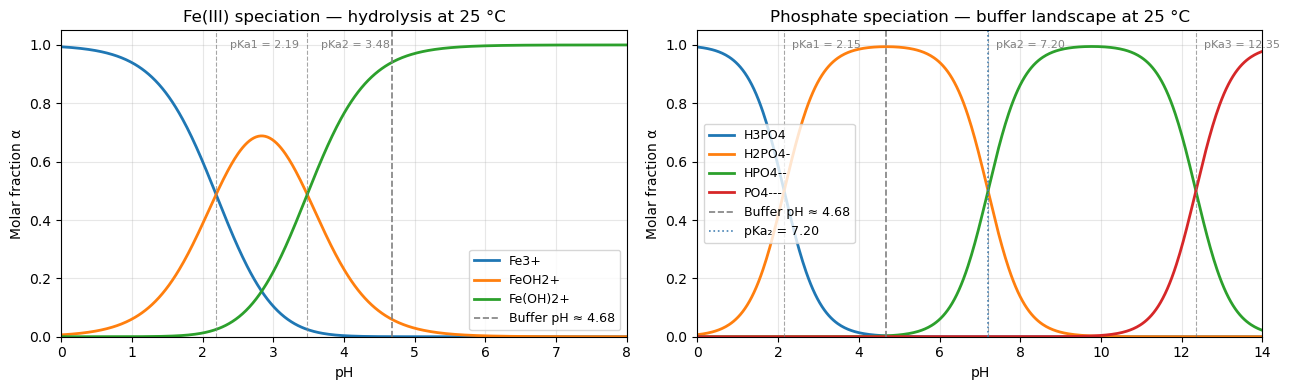

Fe(III) speciation at buffer pH 4.68 (analytical):
  Fe³⁺      0.02%
  FeOH²⁺   5.9%  ← dominant
  Fe(OH)₂⁺ 94.0%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Fe(III) hydrolysis speciation
rxn_system.plot_speciation('Fe3+', T_K=298.15, ax=axes[0], pH_range=(0, 8))
axes[0].axvline(4.68, color='gray', ls='--', lw=1.2, label='Buffer pH ≈ 4.68')
axes[0].legend(fontsize=9)
axes[0].set_title('Fe(III) speciation — hydrolysis at 25 °C')

# Phosphate ladder
rxn_system.plot_speciation('H3PO4', T_K=298.15, ax=axes[1], pH_range=(0, 14))
axes[1].axvline(4.68, color='gray', ls='--', lw=1.2, label='Buffer pH ≈ 4.68')
axes[1].axvline(7.20, color='steelblue', ls=':', lw=1.2, label='pKa₂ = 7.20')
axes[1].legend(fontsize=9)
axes[1].set_title('Phosphate speciation — buffer landscape at 25 °C')

fig.tight_layout()
plt.show()

# Analytical check at buffer pH 4.68
K1, K2 = 10**(-2.19), 10**(-3.48)
H47 = 10**(-4.68)
D47 = 1 + K1/H47 + K1*K2/H47**2
print(f'Fe(III) speciation at buffer pH 4.68 (analytical):')
print(f'  Fe³⁺      {100/D47:.2f}%')
print(f'  FeOH²⁺   {100*K1/H47/D47:.1f}%  ← dominant')
print(f'  Fe(OH)₂⁺ {100*K1*K2/H47**2/D47:.1f}%')

## 3  Batch Simulation

At each integration step the solver:
1. Evaluates the Singer-Stumm kinetic rate (using [OH⁻] from the previous speciation solve)
   and advances Fe²⁺, O₂, Fe³⁺, OH⁻, H₂O by one Euler step.
2. Passes the updated phase to the NR speciation engine, which resolves all seven
   equilibria and returns the self-consistent pH and species distribution.

### 3.1  Predicted behaviour

| # | Prediction | Basis |
|---|---|---|
| 1 | Fe²⁺ > 70% consumed in 20 h | Singer-Stumm rate at pH 4.7; t½ ≈ 1–3 h at demo k |
| 2 | pH buffered near 4.7 ± 0.3 | 220 mM phosphate buffer overwhelms ≈4 mEq OH⁻ produced |
| 3 | FeOH²⁺ dominant in Fe(III) pool | pKh₁ = 2.19 → FeOH²⁺/Fe³⁺ ratio ≈ 320 at pH 4.7 |
| 4 | Total iron conserved to < 0.1% | Mass balance: Fe²⁺ + Fe³⁺ + FeOH²⁺ + Fe(OH)₂⁺ = const |
| 5 | O₂ > 50% depleted | Stoichiometry: 0.75 mM O₂ → capacity for 3.0 mM Fe²⁺ |


### Note
This section is halfway through the full specification of a specific growth mixture. For is required to reconcise molar amounts calculations and their specification within the LiquidPhase instantiation. Aditional reaction equilibria may also be required.

In [5]:
V_L = 1.0     # L
T_K = 298.15  # 25 °C

# ── Compute moles from salt concentrations ────────────────────────────────────
MW_KH2PO4       = 136.09  # g/mol
MW_NH4Cl        = 53.49   # g/mol
MW_K2SO4        = 174.26  # g/mol
MW_MgSO4_7H2O   = 246.47  # g/mol
MW_FeSO4        = 151.90  # g/mol
MW_ZnCl2        = 136.30  # g/mol
MW_MnCl2_4H2O   = 197.90  # g/mol
MW_CuCl2        = 134.50  # g/mol
MW_CoCl2        = 129.80  # g/mol
MW_Na2MoO4      = 205.92  # g/mol
MW_CaCl2        = 110.98  # g/mol
MW_citric_acid  = 192.10  # g/mol
MW_biotin       = 244.30  # g/mol

# Dilution factors for pre-makeup solutions A, B, and C.
A_dilution = 0.85
B_dilution = (0.05/(1 +0.05))
C_dilution = 0.0  # placeholder: biotin is absent until a C stock is defined

def moles_from_g_L(g_L, MW_g_mol, dilution):
    return g_L / MW_g_mol * dilution * V_L

# Salt amounts from pre-makeup solution A (g/L of its undiluted recipe).
n_KH2PO4 = moles_from_g_L(30.0, MW_KH2PO4, A_dilution)
n_NH4Cl  = moles_from_g_L(5.5,  MW_NH4Cl,  A_dilution)
n_K2SO4  = moles_from_g_L(0.4,  MW_K2SO4,  A_dilution)
n_MgSO4  = moles_from_g_L(0.4,  MW_MgSO4_7H2O, A_dilution)

# Salt amounts from pre-makeup solution B. Mn and molybdate masses have
# not yet been specified, so they are explicitly represented as zero.
n_FeSO4       = moles_from_g_L(2.8, MW_FeSO4, B_dilution)
n_ZnCl2       = moles_from_g_L(1.0, MW_ZnCl2, B_dilution)
n_MnCl2_4H2O  = moles_from_g_L(0.0, MW_MnCl2_4H2O, B_dilution)
n_CuCl2       = moles_from_g_L(0.2, MW_CuCl2, B_dilution)
n_CoCl2       = moles_from_g_L(0.2, MW_CoCl2, B_dilution)
n_Na2MoO4     = moles_from_g_L(0.0, MW_Na2MoO4, B_dilution)
n_CaCl2       = moles_from_g_L(2.0, MW_CaCl2, B_dilution)
n_citric_acid = moles_from_g_L(1.5, MW_citric_acid, B_dilution)

# Molar amount from pre-makeup solution C.
n_biotin = moles_from_g_L(0.1, MW_biotin, C_dilution)

n_O2 = 7.5e-4 * V_L  # 0.75 mM dissolved O₂

# Dissociated aqueous-ion inventory. Salts themselves are not species in
# LiquidPhase; these totals are expanded into their aqueous ions below.
n_K   = n_KH2PO4 + 2 * n_K2SO4
n_Na  = 2 * n_Na2MoO4
n_SO4 = n_K2SO4 + n_MgSO4 + n_FeSO4
n_Cl  = n_NH4Cl + 2 * (n_ZnCl2 + n_MnCl2_4H2O + n_CuCl2 + n_CoCl2 + n_CaCl2)
n_Fe2 = n_FeSO4

print('Initial medium (V_L = 1 L):')
for name, val in [('KH₂PO₄', n_KH2PO4), ('NH₄Cl', n_NH4Cl),
                  ('K₂SO₄', n_K2SO4), ('MgSO₄·7H₂O', n_MgSO4),
                  ('FeSO₄', n_FeSO4), ('ZnCl₂', n_ZnCl2),
                  ('CuCl₂', n_CuCl2), ('CoCl₂', n_CoCl2),
                  ('CaCl₂', n_CaCl2), ('citric acid', n_citric_acid),
                  ('biotin', n_biotin), ('O₂', n_O2)]:
    print(f'  {name:<20} {val:.5f} mol  ({val/V_L*1e3:.2f} mM)')

# Charge balance check before speciation (all ions in their dissolution form)
cb_pos = (n_K + n_Na + n_NH4Cl
          + 2*(n_MgSO4 + n_Fe2 + n_ZnCl2 + n_MnCl2_4H2O
               + n_CuCl2 + n_CoCl2 + n_CaCl2))
cb_neg = n_KH2PO4 + n_Cl + 2*(n_SO4 + n_Na2MoO4)
print(f'\nPre-speciation charge balance: {cb_pos:.6f} − {cb_neg:.6f} = {cb_pos - cb_neg:+.2e} Eq')

# ── Build liquid phase ────────────────────────────────────────────────────────
liquid = LiquidPhase(
    n_mol={
        K_plus.id:        n_K,
        Na_plus.id:       n_Na,
        H2PO4_minus.id:   n_KH2PO4,   # total phosphate loaded in H₂PO₄⁻ form
        H3PO4.id:         0.0,
        HPO4_2minus.id:   0.0,
        PO4_3minus.id:    0.0,
        NH4_plus.id:      n_NH4Cl,    # total ammonia-N loaded in NH₄⁺ form
        NH3.id:           0.0,
        Cl_minus.id:      n_Cl,
        SO4_2minus.id:    n_SO4,
        Mg_plus_plus.id:  n_MgSO4,
        Ca_plus_plus.id:  n_CaCl2,
        Zn_plus_plus.id:  n_ZnCl2,
        Mn_plus_plus.id:  n_MnCl2_4H2O,
        Cu_plus_plus.id:  n_CuCl2,
        Co_plus_plus.id:  n_CoCl2,
        MoO4_2minus.id:   n_Na2MoO4,
        'Fe2+':           n_Fe2,
        'Fe3+':           0.0,
        'FeOH2+':         0.0,
        'Fe(OH)2+':       0.0,
        H_plus.id:        2e-5,       # starting guess: pH 4.7
        OH_minus.id:      0.0,
        H2O.id:           55.5,
        O2_aq.id:         n_O2,
        H3Cit.id:         n_citric_acid,
        Biotin.id:        n_biotin,
    },
    V_L=V_L, T_K=T_K,
)

cv = ControlVolume(
    phases={'liquid': liquid},
    reaction_system=rxn_system,
    label='batch_Fe_O2_oxidation',
)
print('\nControl volume assembled.')

# Establish the operating pH before starting the kinetic simulation.
# KOH is represented internally as its strong counter-ion K⁺; the NR
# equilibrium solve supplies the corresponding OH⁻/H⁺ redistribution.
PH_TARGET = 6.5
n_KOH_added = cv.equilibrate_to_pH('KOH', PH_TARGET)
print(f'KOH added: {n_KOH_added * 1e3:.3f} mmol; equilibrated pH: {liquid.pH:.4f}')


Initial medium (V_L = 1 L):
  KH₂PO₄               0.18738 mol  (187.38 mM)
  NH₄Cl                0.08740 mol  (87.40 mM)
  K₂SO₄                0.00195 mol  (1.95 mM)
  MgSO₄·7H₂O           0.00138 mol  (1.38 mM)
  FeSO₄                0.00088 mol  (0.88 mM)
  ZnCl₂                0.00035 mol  (0.35 mM)
  CuCl₂                0.00007 mol  (0.07 mM)
  CoCl₂                0.00007 mol  (0.07 mM)
  CaCl₂                0.00086 mol  (0.86 mM)
  citric acid          0.00037 mol  (0.37 mM)
  biotin               0.00000 mol  (0.00 mM)
  O₂                   0.00075 mol  (0.75 mM)

Pre-speciation charge balance: 0.285896 − 0.285896 = +5.55e-17 Eq

Control volume assembled.


pH correction: added 31.3143 mmol 'KOH' (31.3143 mmol/L).
pH: 4.6854 → 6.5000  (target 6.5000)
KOH added: 31.314 mmol; equilibrated pH: 6.5000


In [6]:
TAU_H   = 24 * 50    # h  (extended to capture Singer-Stumm kinetics at pH 4.7)
N_STEPS = 30000

sim    = Simulation(cvs={'main': cv}, label='Fe_O2_oxidation_batch')
result = sim.run(tau_h=TAU_H, n_steps=N_STEPS)
print(f'Done in {result.runtime_s:.2f} s  ({N_STEPS} steps, dt = {TAU_H/N_STEPS*60:.1f} min)')

Done in 25.29 s  (30000 steps, dt = 2.4 min)


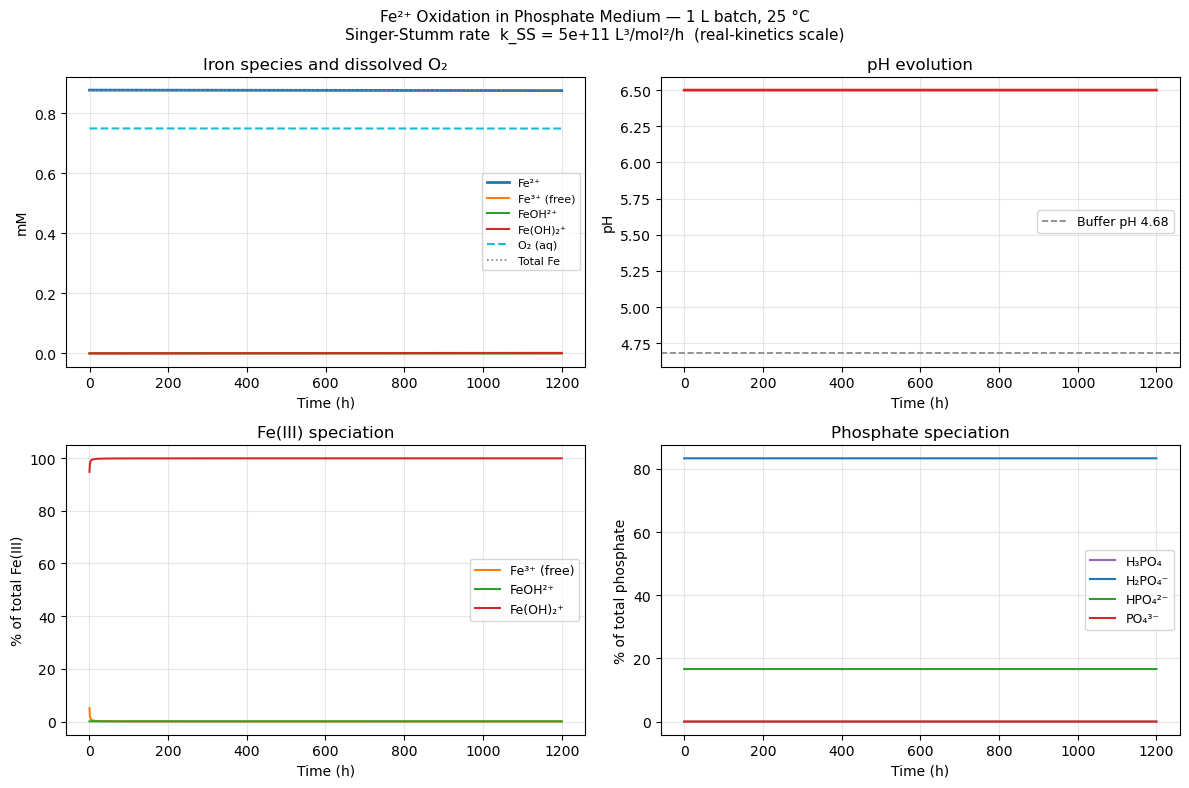

In [7]:
liq = result.liquid_mol['main']
t   = result.t_h
pH  = result.pH['main']

def mM(key): return liq[key] * 1e3

fe3_total = liq['Fe3+'] + liq['FeOH2+'] + liq['Fe(OH)2+']
fe_total  = liq['Fe2+'] + fe3_total
p_total   = liq[H3PO4.id] + liq[H2PO4_minus.id] + liq[HPO4_2minus.id] + liq[PO4_3minus.id]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(
    f'Fe²⁺ Oxidation in Phosphate Medium — 1 L batch, 25 °C\n'
    f'Singer-Stumm rate  k_SS = {K_SS:.0e} L³/mol²/h  (real-kinetics scale)',
    fontsize=11,
)

# ── Iron species + O₂ ────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(t, mM('Fe2+'),     color='tab:blue',   lw=2,   label='Fe²⁺')
ax.plot(t, mM('Fe3+'),     color='tab:orange', lw=1.5, label='Fe³⁺ (free)')
ax.plot(t, mM('FeOH2+'),   color='tab:green',  lw=1.5, label='FeOH²⁺')
ax.plot(t, mM('Fe(OH)2+'), color='tab:red',    lw=1.5, label='Fe(OH)₂⁺')
ax.plot(t, mM('O2'),       color='tab:cyan',   lw=1.5, ls='--', label='O₂ (aq)')
ax.plot(t, fe_total * 1e3, color='gray', ls=':', lw=1.2, label='Total Fe')
ax.set(xlabel='Time (h)', ylabel='mM', title='Iron species and dissolved O₂')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── pH evolution ──────────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(t, pH, color='tab:red', lw=2)
ax.axhline(4.68, color='gray', ls='--', lw=1.2, label='Buffer pH 4.68')
ax.set(xlabel='Time (h)', ylabel='pH', title='pH evolution')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Fe(III) speciation ────────────────────────────────────────────────────────
ax = axes[1, 0]
mask = fe3_total > 1e-9
ax.plot(t[mask], liq['Fe3+'][mask]     / fe3_total[mask] * 100,
        color='tab:orange', label='Fe³⁺ (free)')
ax.plot(t[mask], liq['FeOH2+'][mask]   / fe3_total[mask] * 100,
        color='tab:green',  label='FeOH²⁺')
ax.plot(t[mask], liq['Fe(OH)2+'][mask] / fe3_total[mask] * 100,
        color='tab:red',    label='Fe(OH)₂⁺')
ax.set(xlabel='Time (h)', ylabel='% of total Fe(III)', title='Fe(III) speciation')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Phosphate speciation ──────────────────────────────────────────────────────
ax = axes[1, 1]
ax.plot(t, liq[H3PO4.id]       / p_total * 100, color='tab:purple', label='H₃PO₄')
ax.plot(t, liq[H2PO4_minus.id] / p_total * 100, color='tab:blue',   label='H₂PO₄⁻')
ax.plot(t, liq[HPO4_2minus.id] / p_total * 100, color='tab:green',  label='HPO₄²⁻')
ax.plot(t, liq[PO4_3minus.id]  / p_total * 100, color='tab:red',    label='PO₄³⁻')
ax.set(xlabel='Time (h)', ylabel='% of total phosphate', title='Phosphate speciation')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

In [8]:
print('=' * 60)
print('Prediction verification')
print('=' * 60)

# P1: Fe²⁺ conversion
conv = (1 - liq['Fe2+'][-1] / liq['Fe2+'][0]) * 100
print(f'\nP1  Fe²⁺ conversion at {TAU_H:.0f} h: {conv:.1f}%')
print(f'    [{"PASS" if conv > 70 else "CHECK"}]  (Singer-Stumm at pH 4.7 — demo k)')

# P2: pH buffered by phosphate
pH_valid = pH[np.isfinite(pH)]
pH_init, pH_fin = pH_valid[0], pH_valid[-1]
pH_drift = abs(pH_fin - pH_init)
print(f'\nP2  pH:  initial {pH_init:.3f}  →  final {pH_fin:.3f}  (|Δ| = {pH_drift:.3f})')
print(f'    [{"PASS" if pH_drift < 0.5 else "CHECK"}]  (220 mM phosphate buffer)')

# P3: FeOH²⁺ dominant in Fe(III) pool
if fe3_total[-1] > 1e-9:
    f_fe3  = liq['Fe3+'][-1]   / fe3_total[-1] * 100
    f_feoh = liq['FeOH2+'][-1] / fe3_total[-1] * 100
    f_feh2 = liq['Fe(OH)2+'][-1] / fe3_total[-1] * 100
    print(f'\nP3  Fe(III) split at t = {TAU_H:.0f} h:')
    print(f'    Fe³⁺ {f_fe3:.2f}%   FeOH²⁺ {f_feoh:.1f}%   Fe(OH)₂⁺ {f_feh2:.1f}%')
    print(f'    [{"PASS" if f_feoh > f_fe3 else "CHECK — verify pKa"}]')

# P4: Total iron conserved
drift_pct = abs(fe_total - fe_total[0]).max() / fe_total[0] * 100
print(f'\nP4  Max Fe mass balance drift: {drift_pct:.4f}%  (target < 0.1%)')
print(f'    [{"PASS" if drift_pct < 0.1 else "CHECK"}]')

# P5: O₂ consumption
o2_conv = (1 - liq[O2_aq.id][-1] / liq[O2_aq.id][0]) * 100
print(f'\nP5  O₂ consumed: {o2_conv:.1f}%')
print(f'    Stoichiometric capacity: {4 * liq[O2_aq.id][0] * 1e3:.2f} mM Fe²⁺  (for 0.75 mM O₂)')

Prediction verification

P1  Fe²⁺ conversion at 1200 h: 0.2%
    [CHECK]  (Singer-Stumm at pH 4.7 — demo k)

P2  pH:  initial 6.500  →  final 6.500  (|Δ| = 0.000)
    [PASS]  (220 mM phosphate buffer)

P3  Fe(III) split at t = 1200 h:
    Fe³⁺ 0.00%   FeOH²⁺ 0.1%   Fe(OH)₂⁺ 99.9%
    [PASS]

P4  Max Fe mass balance drift: 0.0000%  (target < 0.1%)
    [PASS]

P5  O₂ consumed: 0.1%
    Stoichiometric capacity: 3.00 mM Fe²⁺  (for 0.75 mM O₂)


## 4  Summary

| Panel | Key result |
|---|---|
| Iron + O₂ | Fe²⁺ depleted as O₂ is consumed; total Fe (dotted) is conserved throughout |
| pH | 220 mM phosphate buffer pins pH near 4.68; small drift from OH⁻ production vs. Fe³⁺ hydrolysis |
| Fe(III) speciation | FeOH²⁺ dominates immediately (pKh₁ = 2.19 — 320:1 ratio over free Fe³⁺ at pH 4.7) |
| Phosphate speciation | H₂PO₄⁻ overwhelmingly dominant; tiny HPO₄²⁻ fraction tracks any pH shifts |

**Key lesson — pH sensitivity of Singer-Stumm kinetics:**
The rate $r \propto [\text{OH}^-]^2$ increases 100-fold per pH unit.
The 220 mM KH₂PO₄ buffer pins pH near 4.7, keeping the reaction slow even at the
10⁹× accelerated demo constant. Raising the buffer pH by 1 unit (to ~5.7) would
accelerate the real reaction 100-fold — from months to days.

**Further extensions:**

- **O₂ mass transfer** — add a `GasPhase` + `KineticTransferModel` to supply O₂
  continuously from a headspace, removing the 0.75 mM stoichiometric limit.
- **pH control** — call `cv.equilibrate_to_pH("NaOH", 6.5)` before running to
  observe dramatically faster Singer-Stumm kinetics above the phosphate buffer range.
- **Precipitation** — add `Fe(OH)₃(s)` via `_precipitation_equilibria` in
  `NRChemicalEquilibriumEngine.from_reactions(...)` to model ferrihydrite formation.
- **Temperature** — supply `dH_J_per_mol` to each `EquilibriumReaction` for
  Van't Hoff corrections at process temperatures (e.g., 37 °C bioreactor).
  - **Uncertainty** — How does uncertainty in the makeup composition affect: 1. the rate of Fe oxidation, and 2. the amount of substance required for pH correction?